In [67]:
# =====================================================================
# PROYECTO 2: PageRank sobre redes reales
# Red elegida: Twitter (ICWSM) / munmun_twitter_social (KONECT)
# =====================================================================
# Fuente: http://konect.cc/networks/munmun_twitter_social/
# Nodos: usuarios de Twitter
# Aristas: relación "sigue a" (follow), dirigida: i -> j significa que i sigue a j
# n = 465.017 nodos, m = 834.797 aristas (cumple con creces el mínimo de 500/2000)
#
# NOTA IMPORTANTE SOBRE EFICIENCIA:
# Con n ~ 465.000, una matriz densa n x n sería intratable
# (465.000^2 ~ 2.16 * 10^11 entradas). Por eso construimos H y S como
# matrices sparse (scipy.sparse), y NUNCA materializamos G como matriz
# densa n x n. En vez de eso, la iteración de potencias se hace con la
# fórmula descompuesta:
#
#   r_(k+1) = alpha * S @ r_k + alpha * (a . r_k)/n * 1 + (1-alpha)/n * 1
#
# donde S es sparse y el término de nodos colgantes (a) se maneja como
# un escalar (producto punto), no como una matriz rango-1 densa.
# =====================================================================

import os
import urllib.request
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import networkx as nx
import collections


In [68]:
# =====================================================================
# P1(a): DESCARGA Y CARGA DE LA RED
# =====================================================================

URL = "http://konect.cc/files/download.tsv.munmun_twitter_social.tar.bz2"
ARCHIVO_COMPRIMIDO = "munmun_twitter_social.tar.bz2"
CARPETA = "munmun_twitter_social"

def descargar_y_descomprimir():
    if not os.path.exists(CARPETA):
        print("Descargando el dataset desde KONECT...")
        urllib.request.urlretrieve(URL, ARCHIVO_COMPRIMIDO)
        print("Descarga completada. Descomprimiendo...")
        os.system(f"tar -xf {ARCHIVO_COMPRIMIDO}")
        os.remove(ARCHIVO_COMPRIMIDO)
        print("Listo.")
    else:
        print("La carpeta ya existe, se omite la descarga.")

descargar_y_descomprimir()

# El archivo de aristas suele llamarse "out.<nombre>" dentro de la carpeta.
# Si KONECT cambia el nombre, revisa el contenido de la carpeta con:
#   print(os.listdir(CARPETA))
archivo_red = os.path.join(CARPETA, "out.munmun_twitter_social")

print("Cargando el grafo dirigido...")
G = nx.read_edgelist(
    archivo_red,
    create_using=nx.DiGraph(),
    comments="%",
    nodetype=int,
    data=False,  # ignoramos posibles columnas extra (peso/timestamp)
)

n = G.number_of_nodes()
m = G.number_of_edges()
print(f"n (nodos) = {n}")
print(f"m (aristas) = {m}")


La carpeta ya existe, se omite la descarga.
Cargando el grafo dirigido...
n (nodos) = 465017
m (aristas) = 834797


In [69]:
# =====================================================================
# P1(b): TABLA DE ESTADÍSTICAS BÁSICAS
# =====================================================================

suma_in = sum(dict(G.in_degree()).values())
suma_out = sum(dict(G.out_degree()).values())
d_in_medio = suma_in / n
d_out_medio = suma_out / n
densidad = m / (n * (n - 1))

nodo_mas_popular, max_in = max(G.in_degree(), key=lambda x: x[1])

nodos_colgantes = [nd for nd in G.nodes() if G.out_degree(nd) == 0]
n_colgantes = len(nodos_colgantes)

print("\n--- TABLA DE ESTADÍSTICAS BÁSICAS (P1) ---")
print(f"n (nodos):                  {n}")
print(f"m (aristas):                {m}")
print(f"Grado de entrada medio:     {d_in_medio:.4f}")
print(f"Grado de salida medio:      {d_out_medio:.4f}")
print(f"Nodo de mayor grado entrada: {nodo_mas_popular} (in-degree = {max_in})")
print(f"Densidad m/(n(n-1)):        {densidad:.10f}")
print(f"Nodos colgantes:            {n_colgantes} ({100*n_colgantes/n:.2f}%)")


--- TABLA DE ESTADÍSTICAS BÁSICAS (P1) ---
n (nodos):                  465017
m (aristas):                834797
Grado de entrada medio:     1.7952
Grado de salida medio:      1.7952
Nodo de mayor grado entrada: 643 (in-degree = 199)
Densidad m/(n(n-1)):        0.0000038605
Nodos colgantes:            462515 (99.46%)


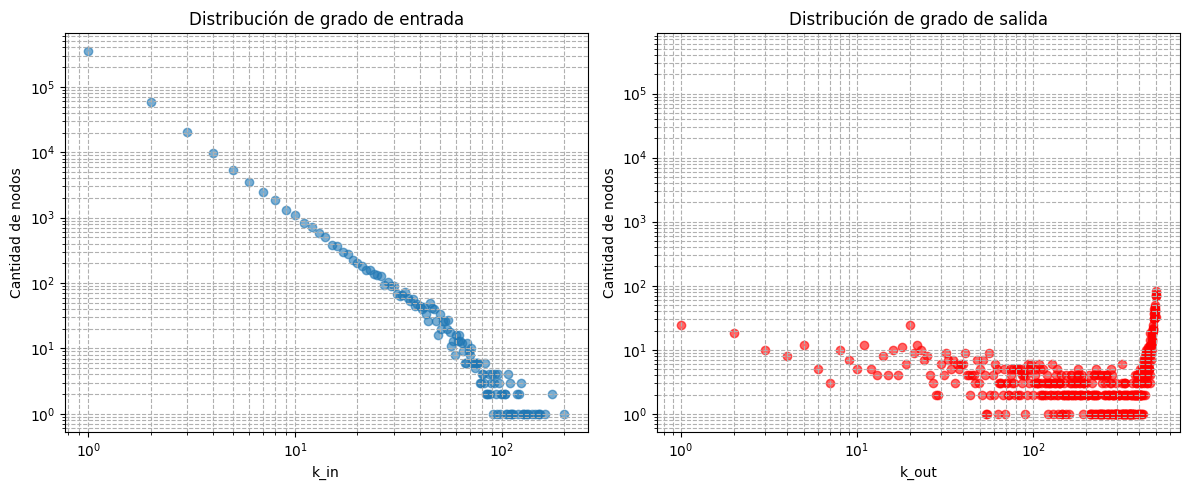


(b) Nodos colgantes: 462515 de 465017 (99.46% de la red). Son problemáticos porque su columna en H queda en cero, haciendo que H no sea columna-estocástica y H^T deje de ser una matriz de transición válida (pierde masa de probabilidad). Se resuelve reemplazando cada columna cero por el vector 1/n en la matriz S.

(c) Top 10 nodos por grado de entrada:
  1. nodo 643 -> in-degree 199
  2. nodo 1405 -> in-degree 174
  3. nodo 5486 -> in-degree 174
  4. nodo 1379 -> in-degree 161
  5. nodo 1471 -> in-degree 153
  6. nodo 2748 -> in-degree 151
  7. nodo 2467 -> in-degree 150
  8. nodo 612 -> in-degree 144
  9. nodo 14047 -> in-degree 139
  10. nodo 5449 -> in-degree 133

Top 10 nodos por grado de salida:
  1. nodo 3418 -> out-degree 500
  2. nodo 5656 -> out-degree 500
  3. nodo 6389 -> out-degree 500
  4. nodo 6595 -> out-degree 500
  5. nodo 6667 -> out-degree 500
  6. nodo 6699 -> out-degree 500
  7. nodo 7780 -> out-degree 500
  8. nodo 8649 -> out-degree 500
  9. nodo 8808 -> out-degr

In [70]:

# =====================================================================
# P3: ANÁLISIS EXPLORATORIO
# =====================================================================

grados_in = np.array([d for _, d in G.in_degree()])
grados_out = np.array([d for _, d in G.out_degree()])

# (a) Distribución de grados (log-log)
conteo_in = collections.Counter(grados_in)
conteo_out = collections.Counter(grados_out)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(list(conteo_in.keys()), list(conteo_in.values()), alpha=0.6)
plt.xscale("log"); plt.yscale("log")
plt.title("Distribución de grado de entrada")
plt.xlabel("k_in"); plt.ylabel("Cantidad de nodos")
plt.grid(True, which="both", ls="--")

plt.subplot(1, 2, 2)
plt.scatter(list(conteo_out.keys()), list(conteo_out.values()), alpha=0.6, color="red")
plt.xscale("log"); plt.yscale("log")
plt.title("Distribución de grado de salida")
plt.xlabel("k_out"); plt.ylabel("Cantidad de nodos")
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.savefig("distribucion_grados.png", dpi=150)
plt.show()

# (b) Nodos colgantes: ya calculados arriba (n_colgantes)
print(f"\n(b) Nodos colgantes: {n_colgantes} de {n} "
      f"({100*n_colgantes/n:.2f}% de la red). "
      "Son problemáticos porque su columna en H queda en cero, "
      "haciendo que H no sea columna-estocástica y H^T deje de ser una "
      "matriz de transición válida (pierde masa de probabilidad). "
      "Se resuelve reemplazando cada columna cero por el vector 1/n "
      "en la matriz S.")



# (c) Top 10 in-degree / out-degree
top10_in = sorted(G.in_degree(), key=lambda x: x[1], reverse=True)[:10]
top10_out = sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:10]

print("\n(c) Top 10 nodos por grado de entrada:")
for i, (nd, d) in enumerate(top10_in, 1):
    print(f"  {i}. nodo {nd} -> in-degree {d}")

print("\nTop 10 nodos por grado de salida:")
for i, (nd, d) in enumerate(top10_out, 1):
    print(f"  {i}. nodo {nd} -> out-degree {d}")

# (d) Conectividad
# OJO: para una red de 465k nodos, nx.is_strongly_connected puede tardar.
# Usamos number_strongly_connected_components / condensation con cuidado.
print("\n(d) Verificando conectividad (puede tardar unos minutos)...")
n_scc = nx.number_strongly_connected_components(G)
tam_scc_max = max(len(c) for c in nx.strongly_connected_components(G))
print(f"Número de componentes fuertemente conexas: {n_scc}")
print(f"Tamaño de la componente fuertemente conexa más grande: {tam_scc_max} "
      f"({100*tam_scc_max/n:.4f}% de la red)")
print("La red NO es fuertemente conexa (esperable en redes sociales grandes). "
      "Sin embargo, la Matriz de Google G es siempre irreducible gracias al "
      "término de teletransportación (1-alpha)/n * 1 1^T, que garantiza "
      "que se pueda llegar de cualquier nodo a cualquier otro con "
      "probabilidad positiva.")


In [71]:
# print("Out-degree mínimo:", grados_out.min())
# print("Out-degree máximo:", grados_out.max())
# print("In-degree mínimo:", grados_in.min())
# print("In-degree máximo:", grados_in.max())

# print("Usuarios con out-degree > 0:",
#       np.sum(grados_out > 0))

# print("Usuarios con in-degree > 0:",
#       np.sum(grados_in > 0))

# print("Primeras 10 líneas del archivo:")

# with open(archivo_red, "r") as f:
#     contador = 0
#     for linea in f:
#         if linea.startswith("%"):
#             continue
#         print(linea.strip())
#         contador += 1
#         if contador == 10:
#             break


# print("Out-degree del nodo 1:", G.out_degree(1))
# print("In-degree del nodo 1:", G.in_degree(1))

# print("¿Existe la arista 1 -> 2?", G.has_edge(1, 2))
# print("¿Existe la arista 2 -> 1?", G.has_edge(2, 1))

In [72]:

# =====================================================================
# P4: CONSTRUCCIÓN DE LA MATRIZ DE GOOGLE (VERSIÓN SPARSE)
# =====================================================================

nodos_ordenados = sorted(G.nodes())
nodo_a_idx = {nd: i for i, nd in enumerate(nodos_ordenados)}

out_degrees = np.array([G.out_degree(nd) for nd in nodos_ordenados])

# --- (a) Matriz de hipervínculos H, en formato sparse (COO -> CSC) ---
filas, columnas, datos = [], [], []
for j_nodo in nodos_ordenados:
    j_idx = nodo_a_idx[j_nodo]
    out_deg = G.out_degree(j_nodo)
    if out_deg > 0:
        peso = 1.0 / out_deg
        for i_nodo in G.successors(j_nodo):
            i_idx = nodo_a_idx[i_nodo]
            filas.append(i_idx)
            columnas.append(j_idx)
            datos.append(peso)

H = sp.csc_matrix((datos, (filas, columnas)), shape=(n, n))

# Verificación: columnas de nodos no colgantes suman 1
sumas_col_H = np.array(H.sum(axis=0)).flatten()
idx_no_colgante = np.where(out_degrees > 0)[0][0]
print(f"\n(P4-a) Suma de la columna de un nodo no colgante en H: "
      f"{sumas_col_H[idx_no_colgante]:.6f} (debe ser 1.0)")

columnas_cero = np.where(out_degrees == 0)[0]
print(f"(P4-a) Columnas cero (nodos colgantes): {len(columnas_cero)} "
      f"({100*len(columnas_cero)/n:.2f}% del total)")

# --- (b) Vector indicador de nodos colgantes 'a' ---
a_vec = (out_degrees == 0).astype(float)  # shape (n,)

# NOTA: no construimos S como matriz densa (H + (1/n) a 1^T).
# En vez de eso, la aplicamos "on the fly" dentro de la iteración de
# potencias como una corrección vectorial, ya que 1^T r = 1 siempre
# (r es una distribución de probabilidad), por lo que:
#   S @ r = H @ r + (1/n) * a * (1^T r) = H @ r + (1/n) * a * sum(r)

# --- (c) Parámetro alpha ---
alpha = 0.85
print(f"\n(P4-c) alpha = {alpha} (valor estándar propuesto por Brin & Page, "
      "balancea la influencia de la estructura real de la red con la "
      "garantía de ergodicidad/convergencia de la cadena de Markov).")




(P4-a) Suma de la columna de un nodo no colgante en H: 1.000000 (debe ser 1.0)
(P4-a) Columnas cero (nodos colgantes): 462515 (99.46% del total)

(P4-c) alpha = 0.85 (valor estándar propuesto por Brin & Page, balancea la influencia de la estructura real de la red con la garantía de ergodicidad/convergencia de la cadena de Markov).



(P5-a) Iteración de potencias convergió en 7 iteraciones (error final = 5.90e-12, tolerancia = 1e-10)


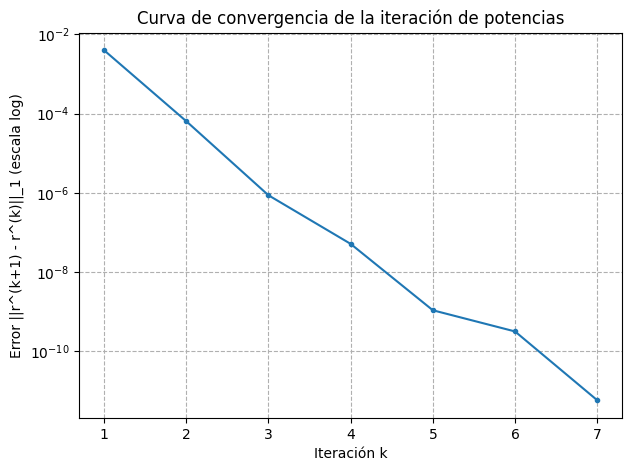

Razón de decaimiento promedio (debería acercarse a alpha=0.85): 0.0297

(P5-c) ||r*||_1 = 1.0000000000 (debe ser 1.0)
        min(r*) = 2.14e-06 (debe ser > 0 para todos los nodos)
Ambas propiedades están garantizadas porque G es una matriz estocástica (columnas suman 1) y estrictamente positiva (ergódica): el teorema de Perron-Frobenius garantiza un único autovector positivo asociado al autovalor 1, normalizado a suma 1.

(P5-d) TOP 20 NODOS POR PAGERANK
rank nodo        pagerank      in-deg    out-deg   
1    5486        0.00000582    174       0         
2    643         0.00000575    199       479       
3    21275       0.00000547    92        0         
4    13847       0.00000460    82        0         
5    612         0.00000451    144       0         
6    5592        0.00000441    124       183       
7    1379        0.00000438    161       0         
8    1405        0.00000436    174       0         
9    3580        0.00000431    127       491       
10   5449        0.0

In [73]:
# =====================================================================
# P5: ITERACIÓN DE POTENCIAS (usando la descomposición sparse de G)
# =====================================================================

def aplicar_G(r, H, a_vec, alpha, n):
    Hr = H @ r
    masa_colgantes = a_vec @ r

    return (
        alpha * Hr
        + alpha * masa_colgantes / n
        + (1 - alpha) / n)

r = np.ones(n) / n
errores = []
max_iter = 500
eps = 1e-10

for k in range(max_iter):
    r_next = aplicar_G(r, H, a_vec, alpha, n)
    error = np.abs(r_next - r).sum()  # norma 1
    errores.append(error)
    r = r_next
    if error < eps:
        break

print(f"\n(P5-a) Iteración de potencias convergió en {k+1} iteraciones "
      f"(error final = {error:.2e}, tolerancia = {eps:.0e})")

# (b) Curva de convergencia (log)
plt.figure(figsize=(7, 5))
plt.semilogy(range(1, len(errores) + 1), errores, marker="o", markersize=3)
plt.xlabel("Iteración k")
plt.ylabel("Error ||r^(k+1) - r^(k)||_1 (escala log)")
plt.title("Curva de convergencia de la iteración de potencias")
plt.grid(True, which="both", ls="--")
plt.savefig("curva_convergencia.png", dpi=150)
plt.show()

# Verificar que la razón de decaimiento es ~ alpha
if len(errores) > 5:
    razones = [errores[i+1]/errores[i] for i in range(len(errores)-1)
               if errores[i] > 0]
    print(f"Razón de decaimiento promedio (debería acercarse a alpha={alpha}): "
          f"{np.mean(razones[:len(razones)//2]):.4f}")

# (c) Verificaciones teóricas
print(f"\n(P5-c) ||r*||_1 = {r.sum():.10f} (debe ser 1.0)")
print(f"        min(r*) = {r.min():.2e} (debe ser > 0 para todos los nodos)")
print("Ambas propiedades están garantizadas porque G es una matriz "
      "estocástica (columnas suman 1) y estrictamente positiva "
      "(ergódica): el teorema de Perron-Frobenius garantiza un único "
      "autovector positivo asociado al autovalor 1, normalizado a suma 1.")

# (d) Tabla top-20 PageRank
idx_top20 = np.argsort(-r)[:20]
print("\n(P5-d) TOP 20 NODOS POR PAGERANK")
print(f"{'rank':<5}{'nodo':<12}{'pagerank':<14}{'in-deg':<10}{'out-deg':<10}")
for rank, idx in enumerate(idx_top20, 1):
    nodo_id = nodos_ordenados[idx]
    print(f"{rank:<5}{nodo_id:<12}{r[idx]:<14.8f}"
          f"{G.in_degree(nodo_id):<10}{G.out_degree(nodo_id):<10}")


In [74]:
masa_colgantes = np.dot(a_vec, r)

print("Masa total del PageRank:", r.sum())
print("Masa en nodos colgantes:", masa_colgantes)
print("Porcentaje:", 100 * masa_colgantes / r.sum())

Masa total del PageRank: 1.000000000000005
Masa en nodos colgantes: 0.9945753194126579
Porcentaje: 99.45753194126527


In [75]:
print("Suma de H @ r:", (H @ r).sum())
print("alpha * suma(H @ r):", (alpha * (H @ r)).sum())
print("Teletransporte total:", n * ((1 - alpha) / n))

Suma de H @ r: 0.005424680587348659
alpha * suma(H @ r): 0.0046109784992463595
Teletransporte total: 0.15000000000000002


In [76]:
print("Número de elementos no nulos de H:", H.nnz)
print("Número de aristas del grafo:", m)

Número de elementos no nulos de H: 834797
Número de aristas del grafo: 834797



(P6-a) Correlación de Pearson (in-degree vs PageRank): 0.6749


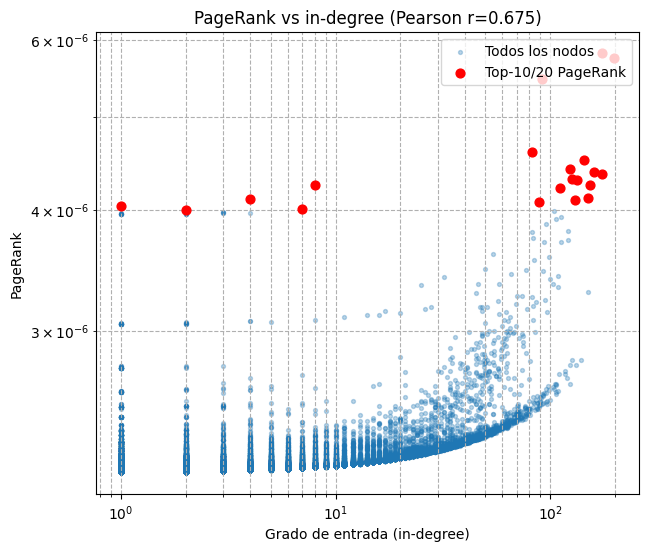


(P6-b) Nodo con alto in-degree pero PageRank relativamente bajo:
  nodo 15161: in-degree=97 (rank #46 global), out-degree=0, PageRank=0.00000253 (rank #420 global de 465017)

Nodo con PageRank alto pero in-degree moderado:
  nodo 400314: PageRank=0.00000396 (rank #37 global), in-degree=1 (rank #400338 global de 465017), out-degree=0


In [77]:
# =====================================================================
# P6: PAGERANK VS. GRADO DE ENTRADA
# =====================================================================

in_deg_array = np.array([G.in_degree(nd) for nd in nodos_ordenados])

# (a) Scatter + correlación de Pearson
correlacion = np.corrcoef(in_deg_array, r)[0, 1]
print(f"\n(P6-a) Correlación de Pearson (in-degree vs PageRank): "
      f"{correlacion:.4f}")

plt.figure(figsize=(7, 6))
plt.scatter(in_deg_array, r, alpha=0.3, s=8, label="Todos los nodos")
plt.scatter(in_deg_array[idx_top20], r[idx_top20], color="red",
            s=40, label="Top-10/20 PageRank", zorder=5)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Grado de entrada (in-degree)")
plt.ylabel("PageRank")
plt.title(f"PageRank vs in-degree (Pearson r={correlacion:.3f})")
plt.legend(loc="upper right")
plt.grid(True, which="both", ls="--")
plt.savefig("pagerank_vs_indegree.png", dpi=150)
plt.show()

# # (b) Nodos donde PageRank e in-degree difieren
# # Ranking relativo de cada nodo en ambas métricas
# rank_pagerank = np.argsort(-r)
# rank_indegree = np.argsort(-in_deg_array)
# pos_pr = {idx: pos for pos, idx in enumerate(rank_pagerank)}
# pos_in = {idx: pos for pos, idx in enumerate(rank_indegree)}

# diffs = [(idx, pos_in[idx] - pos_pr[idx]) for idx in range(n)]
# # Alto in-degree pero PageRank relativamente bajo -> in-degree rank bajo,
# # pagerank rank alto (número grande) => pos_in - pos_pr muy negativo
# diffs_ordenados = sorted(diffs, key=lambda x: x[1])
# print("\n(P6-b) Nodo con alto in-degree pero PageRank bajo (relativo):")
# idx_ejemplo1 = diffs_ordenados[0][0]
# nodo1 = nodos_ordenados[idx_ejemplo1]
# print(f"  nodo {nodo1}: in-degree={G.in_degree(nodo1)}, "
#       f"PageRank={r[idx_ejemplo1]:.8f}")
# print("Nodo con PageRank alto pero in-degree moderado:")
# idx_ejemplo2 = diffs_ordenados[-1][0]
# nodo2 = nodos_ordenados[idx_ejemplo2]
# print(f"  nodo {nodo2}: in-degree={G.in_degree(nodo2)}, "
#       f"PageRank={r[idx_ejemplo2]:.8f}")




# (b) Nodos donde PageRank e in-degree difieren significativamente
# ---------------------------------------------------------------
# En vez de un umbral por percentil (frágil con esta distribución tan
# sesgada), comparamos directamente el TOP-K por in-degree contra su
# ranking global de PageRank, y el TOP-K por PageRank contra su
# ranking global de in-degree. Así evitamos el ruido de los ~99%
# de nodos empatados en in-degree bajo.

K = 50

rank_pagerank_global = np.argsort(-r)              # índices ordenados por PageRank desc
rank_indegree_global = np.argsort(-in_deg_array)    # índices ordenados por in-degree desc

pos_pr_global = {idx: pos for pos, idx in enumerate(rank_pagerank_global)}
pos_in_global = {idx: pos for pos, idx in enumerate(rank_indegree_global)}

# --- Caso 1: alto in-degree pero PageRank relativamente bajo ---
# Tomamos el top-K por in-degree y vemos cuál tiene el peor (mayor)
# ranking global de PageRank.
top_in_idx = rank_indegree_global[:K]
idx_ejemplo1 = max(top_in_idx, key=lambda idx: pos_pr_global[idx])
nodo1 = nodos_ordenados[idx_ejemplo1]
print(f"\n(P6-b) Nodo con alto in-degree pero PageRank relativamente bajo:")
print(f"  nodo {nodo1}: in-degree={G.in_degree(nodo1)} "
      f"(rank #{pos_in_global[idx_ejemplo1]+1} global), "
      f"out-degree={G.out_degree(nodo1)}, "
      f"PageRank={r[idx_ejemplo1]:.8f} "
      f"(rank #{pos_pr_global[idx_ejemplo1]+1} global de {n})")

# --- Caso 2: PageRank alto pero in-degree moderado ---
# Tomamos el top-K por PageRank y vemos cuál tiene el peor (mayor)
# ranking global de in-degree.
top_pr_idx = rank_pagerank_global[:K]
idx_ejemplo2 = max(top_pr_idx, key=lambda idx: pos_in_global[idx])
nodo2 = nodos_ordenados[idx_ejemplo2]
print(f"\nNodo con PageRank alto pero in-degree moderado:")
print(f"  nodo {nodo2}: PageRank={r[idx_ejemplo2]:.8f} "
      f"(rank #{pos_pr_global[idx_ejemplo2]+1} global), "
      f"in-degree={G.in_degree(nodo2)} "
      f"(rank #{pos_in_global[idx_ejemplo2]+1} global de {n}), "
      f"out-degree={G.out_degree(nodo2)}")

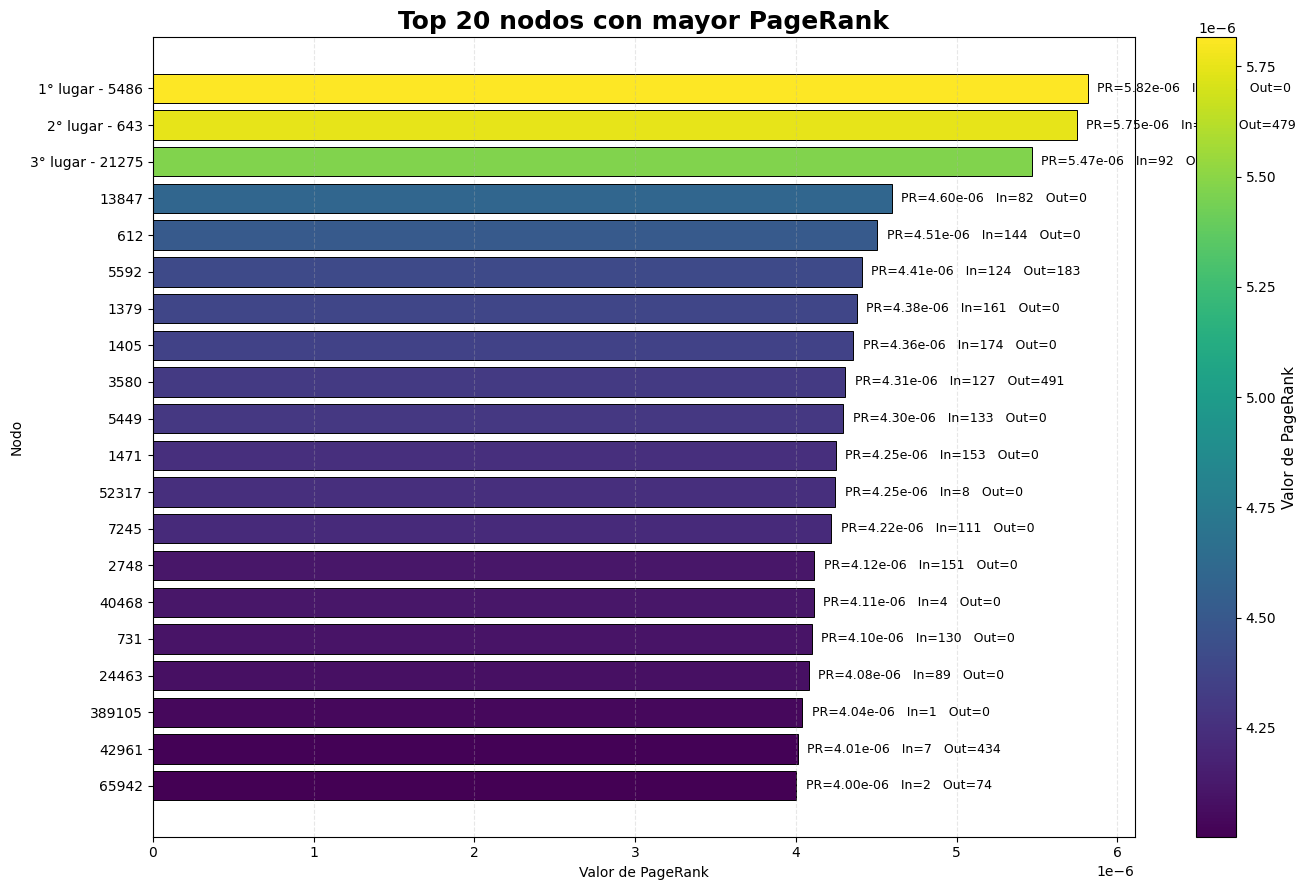

In [78]:
# =====================================================================
# P7 - BLOQUE 1
# TOP 20 NODOS CON MAYOR PAGERANK
# =====================================================================

TOP_K = 20

# Obtener los índices de los TOP 20 PageRank
idx_top = np.argsort(-r)[:TOP_K]

# Información de esos nodos
nodos_top = [nodos_ordenados[i] for i in idx_top]
pagerank_top = np.array([r[i] for i in idx_top])

indegree_top = np.array([
    G.in_degree(n) for n in nodos_top])

outdegree_top = np.array([
    G.out_degree(n) for n in nodos_top])

# ==========================================================
# Crear figura
# ==========================================================

fig, ax = plt.subplots(figsize=(14, 9))

# Colores según el valor de PageRank
norm = plt.Normalize(
    pagerank_top.min(),
    pagerank_top.max())

colors = plt.cm.viridis(
    norm(pagerank_top))

# Crear barras
bars = ax.barh(
    range(TOP_K),
    pagerank_top,
    color=colors,
    edgecolor="black",
    linewidth=0.7)

# Colocar el mejor nodo arriba
ax.invert_yaxis()

# ==========================================================
# Etiquetas eje Y
# ==========================================================

labels = [
    f"{i+1}° lugar - {nodo}" if i < 3 else str(nodo)
    for i, nodo in enumerate(nodos_top)]

ax.set_yticks(range(TOP_K))
ax.set_yticklabels(labels)

# ==========================================================
# Valores sobre las barras
# ==========================================================

for i in range(TOP_K):

    texto = (
        f"PR={pagerank_top[i]:.2e}   "
        f"In={indegree_top[i]}   "
        f"Out={outdegree_top[i]}")

    ax.text(
        pagerank_top[i] + pagerank_top.max()*0.01,
        i,
        texto,
        va="center",
        fontsize=9)

# ==========================================================
# Barra de color
# ==========================================================

sm = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=norm)

sm.set_array([])
cbar = fig.colorbar(
    sm,
    ax=ax)

cbar.set_label(
    "Valor de PageRank",
    fontsize=11)

# ==========================================================
# Decoración
# ==========================================================

ax.set_title(
    "Top 20 nodos con mayor PageRank",
    fontsize=18,
    weight="bold")

ax.set_xlabel(
    "Valor de PageRank")

ax.set_ylabel(
    "Nodo")

ax.grid(
    axis="x",
    alpha=0.3,
    linestyle="--")

plt.tight_layout()

# Guardar figura
plt.savefig(
    "P7_Bloque1_Top20_PageRank.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

In [ ]:
# =====================================================================
# P7 - BLOQUE 2
# RELACIÓN IN-DEGREE vs PAGERANK
# =====================================================================

# Calcular grados
indegree = np.array([
    G.in_degree(n)
    for n in nodos_ordenados])

outdegree = np.array([
    G.out_degree(n)
    for n in nodos_ordenados])

pagerank = np.array(r)

# ==========================================================
# Correlación de Pearson
# ==========================================================

correlacion = np.corrcoef(
    indegree,
    pagerank)[0, 1]

print(f"Correlación de Pearson (in-degree vs PageRank): {correlacion:.4f}")

# ==========================================================
# Crear figura y eje
# ==========================================================

fig, ax = plt.subplots(
    figsize=(12, 8))

# ==========================================================
# Escala de colores según PageRank
# ==========================================================

norm = plt.Normalize(
    pagerank.min(),
    pagerank.max())

colors = plt.cm.viridis(
    norm(pagerank))

# ==========================================================
# Tamaño según out-degree
# ==========================================================

sizes = (np.log1p(outdegree) + 1) * 20

# ==========================================================
# Scatter
# ==========================================================
ax.scatter(
    indegree,
    pagerank,
    c=colors,
    s=sizes,
    alpha=0.7,
    edgecolors="none")

# ==========================================================
# Línea de tendencia
# ==========================================================

# Ajuste lineal en escala log
x_log = np.log10(indegree + 1)

# Evitar log(0)
y_log = np.log10(
    pagerank + 1e-12)

coef = np.polyfit(
    x_log,
    y_log,
    1)

x_line = np.linspace(
    x_log.min(),
    x_log.max(),
    200)

y_line = np.polyval(
    coef,
    x_line)

ax.plot(
    10**x_line - 1,
    10**y_line,
    linestyle="--",
    linewidth=2)

# ==========================================================
# Escalas logarítmicas
# ==========================================================
ax.set_xscale("log")
ax.set_yscale("log")

# ==========================================================
# Barra de color
# ==========================================================
sm = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=norm)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax)

cbar.set_label(
    "PageRank",
    fontsize=11)

# ==========================================================
# Leyenda tamaño Out-degree
# ==========================================================

for grado in [1, 10, 100, 1000]:

    ax.scatter(
        [],
        [],
        s=(np.log1p(grado)+1)*20,
        label=str(grado))

ax.legend(
    title="Out-degree (tamaño)",
    scatterpoints=1,
    loc="lower right")

# ==========================================================
# Decoración
# ==========================================================

ax.set_title(
    "Relación In-degree vs PageRank",
    fontsize=18,
    weight="bold")

ax.set_xlabel(
    "In-degree (escala log)")

ax.set_ylabel(
    "PageRank (escala log)")

ax.text(
    0.65,
    0.15,
    f"Correlación de Pearson\nr = {correlacion:.4f}",
    transform=ax.transAxes,
    fontsize=12,
    bbox=dict(
        alpha=0.2))

ax.grid(
    alpha=0.3,
    linestyle="--")


plt.tight_layout()

plt.savefig(
    "P7_Bloque2_InDegree_vs_PageRank.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

Correlación de Pearson (in-degree vs PageRank): 0.6749


In [ ]:
# =====================================================================
# P7 - BLOQUE 3
# SUBGRAFO TOP 20 NODOS CON MAYOR PAGERANK
# =====================================================================

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np


# ==========================================================
# TOP 20 nodos
# ==========================================================

TOP_K = 20

idx_top = np.argsort(-r)[:TOP_K]

top_nodes = [
    nodos_ordenados[i]
    for i in idx_top
]


# Subgrafo TOP 20
G_top = G.subgraph(top_nodes).copy()



# ==========================================================
# PageRank de los nodos
# ==========================================================

pagerank_top = {
    nodo: r[nodos_ordenados.index(nodo)]
    for nodo in top_nodes
}



# ==========================================================
# Layout
# ==========================================================

pos = nx.spring_layout(
    G_top,
    seed=7,
    k=1.8,
    iterations=200
)



# ==========================================================
# Tamaño nodos según PageRank
# ==========================================================

sizes = np.array([
    pagerank_top[n]
    for n in G_top.nodes()
])


node_sizes = (
    sizes / sizes.max()
) * 2500 + 600



# ==========================================================
# Color nodos
# ==========================================================

node_colors = [
    pagerank_top[n]
    for n in G_top.nodes()
]



# ==========================================================
# Grosor de flechas según origen
# ==========================================================

edge_widths = []

max_pr = max(pagerank_top.values())

for u, v in G_top.edges():

    width = (
        pagerank_top[u] /
        max_pr
    )

    edge_widths.append(
        width * 5
    )



# ==========================================================
# Figura
# ==========================================================

fig, ax = plt.subplots(
    figsize=(14,10)
)



# ==========================================================
# Aristas
# ==========================================================

nx.draw_networkx_edges(
    G_top,
    pos,
    width=edge_widths,
    edge_color="gray",
    alpha=0.45,
    arrows=True,
    arrowsize=18,
    arrowstyle="-|>",
    ax=ax
)



# ==========================================================
# Nodos
# ==========================================================

nodes = nx.draw_networkx_nodes(
    G_top,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap="viridis",
    alpha=0.95,
    edgecolors="black",
    linewidths=1.5,
    ax=ax
)



# ==========================================================
# Etiquetas blancas
# ==========================================================

labels = {}

for n in G_top.nodes():

    labels[n] = (
        f"{n}\n"
        f"{pagerank_top[n]:.2e}"
    )


nx.draw_networkx_labels(
    G_top,
    pos,
    labels,
    font_size=8,
    font_weight="bold",
    font_color="white",
    ax=ax
)



# ==========================================================
# Barra de color
# ==========================================================

sm = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=plt.Normalize(
        min(node_colors),
        max(node_colors)
    )
)

sm.set_array([])


cbar = fig.colorbar(
    sm,
    ax=ax
)


cbar.set_label(
    "Escala PageRank (color)",
    fontsize=11
)



# ==========================================================
# Leyenda grosor flechas
# ==========================================================

for label, width in [
    ("Alto",5),
    ("Medio",2.5),
    ("Bajo",0.8)
]:

    ax.plot(
        [],
        [],
        linewidth=width,
        color="black",
        label=label
    )


ax.legend(
    title="Escala PageRank\n(origen)",
    loc="lower right"
)



# ==========================================================
# Título
# ==========================================================

ax.set_title(
    "Subgrafo de los 20 nodos con mayor PageRank",
    fontsize=18,
    weight="bold"
)


ax.axis("off")


plt.tight_layout()


plt.savefig(
    "P7_Bloque3_Subgrafo_TOP20_PageRank.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()